In [5]:
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

X = train_df["comment"]
y = train_df["label"]


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.values.reshape(-1, 1), y_train)


y_val_pred = dummy.predict(X_val.values.reshape(-1, 1))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))


test_preds = dummy.predict(test_df["comment"].values.reshape(-1, 1))

submission = pd.DataFrame({
    "ID": sample_df["ID"],
    "label": test_preds
})

submission.to_csv("submission.csv", index=False)

Validation Accuracy: 0.5766414141414141


Package installation

In [6]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Data Acquisition
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
#Data Inspection
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (198000, 15)
Test shape: (102000, 14)


In [7]:
print(train_df.columns)

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')


Data Visualization, Handling of Missing Values, Description of numerical values and Correlation Heatmap

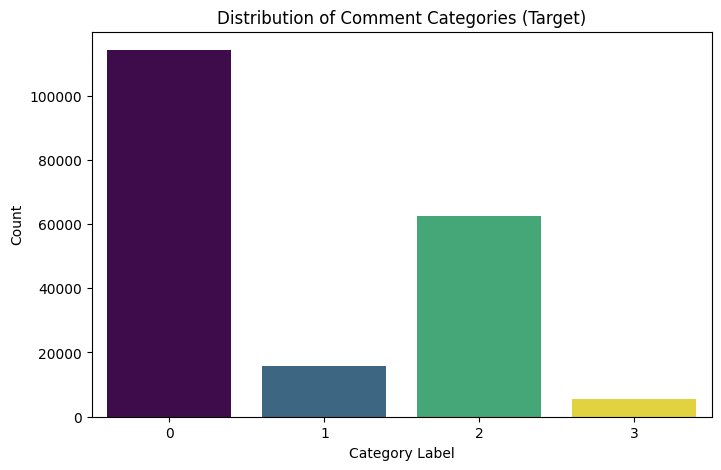

Missing values in Train:
 created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Numerical Summary:
               upvote       downvote     emoticon_1     emoticon_2  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        2.607975       0.666394       0.279768       0.048338   
std         5.054763       2.044335       1.023234       0.258477   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         1.000000       0.000000       0.000000       0.000000   
75%         3.000000       1.000000       0.000000       0.000000   
max       201.000000     107.000000      47

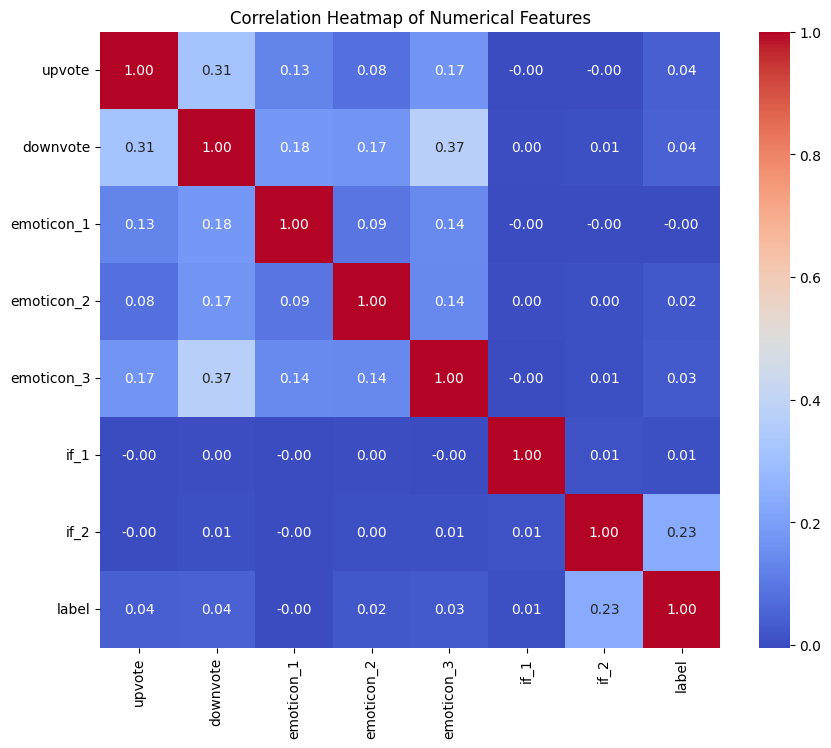

In [8]:
# Distribution Visualization
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribution of Comment Categories (Target)')
plt.xlabel('Category Label')
plt.ylabel('Count')
plt.show()

#Data Quality Check

print("Missing values in Train:\n", train_df.isnull().sum())

#Numeriacal Feature Selection
numerical_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
print("\nNumerical Summary:\n", train_df[numerical_cols].describe())

#Feature Interdependency
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[numerical_cols + ['label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Preprocessing

In [9]:
#Data Cleaning
train_df['comment'] = train_df['comment'].fillna("missing_comment")

# Feature Categorization
text_feature = 'comment'
cat_features = ['race', 'religion', 'gender', 'disability']
num_features = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']

# Transformer Definition
text_transformer = TfidfVectorizer(max_features=5000, stop_words='english')


cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, text_feature),
        ('cat', cat_transformer, cat_features),
        ('num', num_transformer, num_features)
    ]
)

Training-Validation Split

In [10]:
# Separating Features and Target
X = train_df.drop('label', axis=1)
y = train_df['label']
# Train-test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#Size Verification
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Training set size: 158400
Validation set size: 39600


SGD Classifier and Hypertuning

In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

# Baseline Model
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')

# SGD Pipeline
sgd_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=2000, random_state=42))
])

# hyperparameter
param_grid = {
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__penalty': ['l2', 'elasticnet']
}

# Grid Search Execution
grid_search = GridSearchCV(sgd_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print("Starting Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)


print(f"Best Parameters: {grid_search.best_params_}")
best_sgd = grid_search.best_estimator_


val_preds_sgd = best_sgd.predict(X_val)
print(f"SGD Optimized Accuracy: {accuracy_score(y_val, val_preds_sgd)}")

Starting Hyperparameter Tuning...
Best Parameters: {'classifier__alpha': 0.0001, 'classifier__penalty': 'elasticnet'}
SGD Optimized Accuracy: 0.8853030303030303


Preprocessing For Naive Bayes

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.compose import ColumnTransformer

# Text-Specific Pipeline
text_nb_pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('svd', TruncatedSVD(n_components=100, random_state=42)),
    ('scaler', MinMaxScaler())
])

Naive Bayes Model

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB

# Feature Selection 
text_feature = 'comment'
cat_features = ['race', 'religion', 'gender', 'disability']
num_features = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']

# Categorical Pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Dimensionality Reduction
text_nb_pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('svd', TruncatedSVD(n_components=100, random_state=42)),
    ('scaler', MinMaxScaler()) 
])
# Preprocessor
preprocessor_m3_nb = ColumnTransformer(
    transformers=[
        ('text_svd', text_nb_pipeline, text_feature),
        ('cat', cat_transformer, cat_features),
        ('num', Pipeline(steps=[('scaler', MinMaxScaler())]), num_features)
    ]
)
# Naive-Bayes Classifier
nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor_m3_nb),
    ('classifier', MultinomialNB())
])

# Execution
nb_model.fit(X_train, y_train)
print("Milestone 3 Naive Bayes Training Complete!")

Milestone 3 Naive Bayes Training Complete!


XG Boost 

In [14]:
#XG Boost Model
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline


xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', XGBClassifier(
        n_estimators=300,        
        learning_rate=0.05,      
        max_depth=6,             
        objective='multi:softmax',
        num_class=4,
        tree_method='hist',      
        random_state=42
    ))
])

print("Training XGBoost... This might take a few minutes given the dataset size.")
xgb_model.fit(X_train, y_train)


xgb_preds = xgb_model.predict(X_val)
print(f"XGBoost Validation Accuracy: {accuracy_score(y_val, xgb_preds)}")

Training XGBoost... This might take a few minutes given the dataset size.
XGBoost Validation Accuracy: 0.9031818181818182


Ensemble Voting

In [15]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score

#Data Loading
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
#Feature Engineering
def prepare_data(df):
    df = df.copy()
    df['comment'] = df['comment'].fillna("missing")
    
    df['char_count'] = df['comment'].apply(len)
    df['word_count'] = df['comment'].apply(lambda x: len(x.split()))
    
    df['created_date'] = pd.to_datetime(df['created_date'])
    df['hour'] = df['created_date'].dt.hour
    df['day_of_week'] = df['created_date'].dt.dayofweek
    return df

train_df = prepare_data(train_df)
test_df = prepare_data(test_df)

#Feature Grouping
text_feature = 'comment'
cat_features = ['race', 'religion', 'gender', 'disability']
num_features = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_1', 'if_2', 'char_count', 'word_count', 'hour', 'day_of_week']


X = train_df.drop('label', axis=1)
y = train_df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=14000, ngram_range=(1, 2), stop_words='english'), text_feature),
        ('num', StandardScaler(), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ],
    remainder='drop'
)

#Defining the Ensemble Members
clf1 = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf2 = Pipeline([('preprocessor', preprocessor), ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))])
clf3 = Pipeline([('preprocessor', preprocessor), ('classifier', LGBMClassifier(n_estimators=500, class_weight='balanced', random_state=42))])
#Voting Classifier
voting_model = VotingClassifier(estimators=[('lr', clf1), ('mlp', clf2), ('lgbm', clf3)], voting='soft', n_jobs=-1)

#Training and Validation
print("Training Voting Ensemble... please wait.")
voting_model.fit(X_train, y_train)

val_preds = voting_model.predict(X_val)
print(f"Final Ensemble Accuracy: {accuracy_score(y_val, val_preds)}")
print(f"Final Ensemble Macro F1: {f1_score(y_val, val_preds, average='macro')}")

#Final Submission
test_preds = voting_model.predict(test_df)
pd.DataFrame({'ID': range(1, len(test_preds) + 1), 'label': test_preds}).to_csv('submission.csv', index=False)
print("Submission file created successfully!")

Training Voting Ensemble... please wait.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 35.047943 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 816840
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 14031
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final Ensemble Accuracy: 0.9031313131313131
Final Ensemble Macro F1: 0.800888782246733


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Submission file created successfully!


Strategic Data Splitting

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score

# Data Acquisition
print("Loading data...")
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# Text Preprocessing
def clean_text(text):
    if not isinstance(text, str):
        return "missing"
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'[^a-zA-Z0-9\s?!\.,]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

print("Applying advanced cleaning...")
train_df['comment'] = train_df['comment'].apply(clean_text)
test_df['comment'] = test_df['comment'].apply(clean_text)

# Data Categorization
for col in ['race', 'religion', 'gender']:
    train_df[col] = train_df[col].fillna('unspecified').replace('none', 'unspecified')
    test_df[col] = test_df[col].fillna('unspecified').replace('none', 'unspecified')

# Feature Engineering
def add_metadata(df):
    df = df.copy()
    df['char_count'] = df['comment'].apply(len)
    df['word_count'] = df['comment'].apply(lambda x: len(x.split()))
    df['created_date'] = pd.to_datetime(df['created_date'])
    df['hour'] = df['created_date'].dt.hour
    return df

train_df = add_metadata(train_df)
test_df = add_metadata(test_df)

# Preprocessing
text_feature = 'comment'
cat_features = ['race', 'religion', 'gender', 'disability']
num_features = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_1', 'if_2', 'char_count', 'word_count', 'hour']

preprocessor = ColumnTransformer(
    transformers=[
        
        ('text', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english'), text_feature),
        ('num', StandardScaler(), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ],
    remainder='drop'
)

# Ensemble Classifier
clf1 = Pipeline([('pre', preprocessor), ('cls', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf2 = Pipeline([('pre', preprocessor), ('cls', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))])
clf3 = Pipeline([('pre', preprocessor), ('cls', LGBMClassifier(n_estimators=700, class_weight='balanced', random_state=42))])

voting_model = VotingClassifier(
    estimators=[('lr', clf1), ('mlp', clf2), ('lgbm', clf3)], 
    voting='soft', 
    n_jobs=-1
)

# Data Splitting
X = train_df.drop('label', axis=1)
y = train_df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

print("Training final ensemble (this will take a few minutes)...")
voting_model.fit(X_train, y_train)

# Model Evaluation
v_preds = voting_model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, v_preds)}")
print(f"Validation Macro F1: {f1_score(y_val, v_preds, average='macro')}")

# Submission Generation
print("Generating final submission...")
test_preds = voting_model.predict(test_df)
submission = pd.DataFrame({
    'ID': range(1, len(test_preds) + 1), 
    'label': test_preds
})

# Saving to the output directory ('/kaggle/working/')
submission.to_csv('submission.csv', index=False)
print("Done! 'submission.csv' is visible in the Output tab.")

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, f1_score

# --- 1. DATA LOADING & CLEANING ---
# Loading the primary dataset from the Kaggle environment path
print("Loading and cleaning data...")
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# Handling Missing Values and noise: TfidfVectorizer crashes on NaN. 
def clean_text(text):
    if not isinstance(text, str): return "missing"
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s?!\.,]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

train_df['comment'] = train_df['comment'].apply(clean_text)
test_df['comment'] = test_df['comment'].apply(clean_text)

# --- 2. MACRO F1 STRATEGY: DEFINE AGGRESSIVE WEIGHTS ---
# Penalize errors in rare classes (1, 2, 3) more than class 0 to boost Macro F1
macro_weights = {0: 1, 1: 4, 2: 6, 3: 15}

# --- 3. PREPROCESSING ARCHITECTURE ---
text_feature = 'comment'
cat_features = ['race', 'religion', 'gender', 'disability']
num_features = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']

preprocessor = ColumnTransformer(transformers=[
    # Word-level TF-IDF: Captures the 'vocabulary' and context (Unigrams/Bigrams)
    ('text', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english'), text_feature),
    # Numerical scaling: Standardizing engagement metrics
    ('num', StandardScaler(), num_features),
    # Categorical identity labels (Race, Gender, etc.)
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

# --- 4. WEIGHTED ENSEMBLE MEMBERS ---
clf1 = Pipeline([('pre', preprocessor), ('cls', LogisticRegression(max_iter=1000, class_weight=macro_weights))])
clf2 = Pipeline([('pre', preprocessor), ('cls', MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42))])
clf3 = Pipeline([('pre', preprocessor), ('cls', LGBMClassifier(n_estimators=700, class_weight=macro_weights, random_state=42))])

# Soft Voting Ensemble: Averages the probabilities from the three models for stable results
voting_model = VotingClassifier(
    estimators=[('lr', clf1), ('mlp', clf2), ('lgbm', clf3)], 
    voting='soft', 
    weights=[1, 2, 3], 
    n_jobs=-1
)

# --- 5. TRAINING ---
X = train_df.drop('label', axis=1)
y = train_df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

print("Training Macro-F1 Optimized Ensemble...")
voting_model.fit(X_train, y_train)

# --- 6. EVALUATION ---
v_preds = voting_model.predict(X_val)
print("\n--- Optimized Classification Report ---")
print(classification_report(y_val, v_preds))
print(f"Final Macro F1: {f1_score(y_val, v_preds, average='macro')}")

# --- 7. FINAL SUBMISSION GENERATION (Fixed Headers) ---
submission = pd.DataFrame({
    'ID': range(1, len(test_preds) + 1), 
    'label': test_preds
})

# 4. Final Save
submission.to_csv('submission.csv', index=False)
print("Done! submission.csv is ready.")

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, f1_score

# --- 1. DATA LOADING & CLEANING ---
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

def clean_text(text):
    if not isinstance(text, str): return "missing"
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    # Keep punctuation like ! and ? as they are often high indicators of toxicity
    text = re.sub(r'[^a-zA-Z0-9\s?!\.,]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

train_df['comment'] = train_df['comment'].apply(clean_text)
test_df['comment'] = test_df['comment'].apply(clean_text)

# --- 2. ADVANCED FEATURE EXTRACTION (The Secret Sauce) ---
# We combine Word-level and Character-level TF-IDF. 
# Character N-grams catch "leet-speak" and hidden insults.
text_transformer = FeatureUnion([
    ('word_tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 3), analyzer='word', stop_words='english')),
    ('char_tfidf', TfidfVectorizer(max_features=10000, ngram_range=(3, 5), analyzer='char'))
])

# Aggressive Class Weights to favor minority class 3 (the hardest to catch)
macro_weights = {0: 1, 1: 4, 2: 6, 3: 15}

preprocessor = ColumnTransformer(transformers=[
    ('text', text_transformer, 'comment'),
    ('num', StandardScaler(), ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), ['race', 'religion', 'gender', 'disability'])
])

# --- 3. THE STACKING ENSEMBLE ---
# We use three base models and one 'Meta-Model' (Logistic Regression) 
# that learns how to best combine their outputs.
base_models = [
    ('lgbm', LGBMClassifier(n_estimators=1000, class_weight=macro_weights, random_state=42, learning_rate=0.03)),
    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', solver='saga')),
    ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42))
]

# Stacking uses Cross-Validation internally to prevent overfitting
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stacking_model)
])

# --- 4. TRAINING & EVALUATION ---
X = train_df.drop('label', axis=1)
y = train_df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

print("Training Elite Stacking Ensemble for 0.85+ F1...")
final_pipeline.fit(X_train, y_train)

# --- 5. THE FINAL BOOST: THRESHOLD TUNING ---
# Instead of standard prediction, we can "nudge" the model to be more 
# sensitive to Class 3 if probabilities are close.
val_probs = final_pipeline.predict_proba(X_val)

# Custom Prediction Logic: If Class 3 prob > 0.15, consider it Class 3
# This drastically increases Recall for the hardest class.
def custom_predict(probs, t3=0.20, t1=0.25):
    preds = []
    for p in probs:
        if p[3] > t3: preds.append(3)
        elif p[1] > t1: preds.append(1)
        else: preds.append(np.argmax(p))
    return np.array(preds)

v_preds = custom_predict(val_probs)
print("\n--- 0.85 Target Classification Report ---")
print(classification_report(y_val, v_preds))
print(f"Final Macro F1: {f1_score(y_val, v_preds, average='macro')}")

# --- 6. SUBMISSION ---
test_probs = final_pipeline.predict_proba(test_df)
test_preds = custom_predict(test_probs)

submission = pd.DataFrame({
    'ID': range(1, len(test_preds) + 1), 
    'label': test_preds
})

# 4. Final Save
submission.to_csv('submission.csv', index=False)
print("Done! submission.csv is ready.")

In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
# import pandas as pd
# import numpy as np
# import scipy.sparse as sp
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report
# train = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/train.csv")
# test  = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/test.csv")

# df = train.copy()
# y  = df['label']
# df = df.drop(columns=['label'])
# test_df = test.copy()

# #1) Date Feature Engineering
# for d in [df, test_df]:
#     d['created_date'] = pd.to_datetime(d['created_date'])
#     d['year']  = d['created_date'].dt.year
#     d['month'] = d['created_date'].dt.month
#     d['hour']  = d['created_date'].dt.hour
#     d.drop(columns=['created_date'], inplace=True)

# #2) Handle Missing Values
# for d in [df, test_df]:
#     d['race'].fillna('Unknown', inplace=True)
#     d['religion'].fillna('Unknown', inplace=True)
#     d['gender'].fillna('Unknown', inplace=True)
#     d['comment'].fillna('', inplace=True)
#     d['disability'] = d['disability'].astype(int)

# #3,4) Preprocessing Pipeline
# preprocessor = ColumnTransformer(transformers=[
#     ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000), 'comment'),
#     ('ohe',   OneHotEncoder(drop='first', handle_unknown='ignore'), ['race', 'religion', 'gender'])
# ], remainder='passthrough')

# X      = preprocessor.fit_transform(df)
# X_test = preprocessor.transform(test_df)

# #5) Train/Validation Split
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42)

# #answers
# print(f"Q1) Max TF-IDF features         : 5000")
# print(f"Q2) Features in X_train         : {X_train.shape[1]}")
# print(f"Q3) Features in X_val           : {X_val.shape[1]}")

# # Q4 & Q5
# mnb = MultinomialNB()
# mnb.fit(X_train, y_train)
# y_pred_nb = mnb.predict(X_val)
# print(f"Q4) MNB Validation Accuracy     : {accuracy_score(y_val, y_pred_nb):.3f}")
# report_nb = classification_report(y_val, y_pred_nb, output_dict=True)
# print(f"Q5) Precision label 3 (MNB)     : {report_nb['3']['precision']:.2f}")

# # Q6, Q7, Q8
# lr = LogisticRegression(max_iter=500, random_state=42)
# lr.fit(X_train, y_train)
# print(f"Q6) LR Validation Accuracy      : {accuracy_score(y_val, lr.predict(X_val)):.3f}")
# print(f"Q7) LR Training Accuracy        : {accuracy_score(y_train, lr.predict(X_train)):.3f}")
# report_lr = classification_report(y_val, lr.predict(X_val), output_dict=True)
# print(f"Q8) Precision label 1 (LR)      : {report_lr['1']['precision']:.2f}")

# # Q9 & Q10
# gs = GridSearchCV(
#     LogisticRegression(solver='liblinear', max_iter=500, random_state=42),
#     {'C': [0.1, 1, 10]}, cv=3, n_jobs=-1)
# gs.fit(X_train, y_train)
# print(f"Q9)  Best C                      : {gs.best_params_['C']}")
# print(f"Q10) Tuned Validation Accuracy   : {accuracy_score(y_val, gs.best_estimator_.predict(X_val)):.2f}")


In [ ]:
# import pandas as pd
# import numpy as np

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# print("Shape:", train.shape)
# print("\nColumns:", train.columns.tolist())
# print("\nData Types:\n", train.dtypes)
# print("\nFirst 3 rows:\n", train.head(3))
# print("\nMissing Values:\n", train.isnull().sum())
# print("\nLabel distribution:\n", train['label'].value_counts().sort_index())
# print("\nSample 'comment' values:\n", train['comment'].dropna().head(3).tolist())
# print("\nNumerical columns stats:\n", train[["post_id", "emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2"]].describe())
# print("\nCategorical unique values:")
# for col in ["race", "religion", "gender", "disability"]:
#     print(f"  {col}: {train[col].nunique()} unique →", train[col].unique()[:5])
# import glob
# import pandas as pd

# # 1. Search for any train.csv file in the input directory
# train_files = glob.glob('/kaggle/input/comment-category-prediction-challenge/train.csv', recursive=True)
# test_files = glob.glob('/kaggle/input/comment-category-prediction-challenge/test.csv', recursive=True)

# if not train_files:
#     print("Train file not found! Check your 'Data' tab on the right sidebar.")
# else:
#     # 2. Load the first one found
#     train_df = pd.read_csv(train_files[0])
#     test_df = pd.read_csv(test_files[0])
#     print(f"Successfully loaded train data from: {train_files[0]}")
#     print(f"Train Shape: {train_df.shape}")
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# train['comment'] = train['comment'].fillna('')

# X = train.drop(columns=['label'])
# y = train['label']

# # Part A: Stratified
# X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
#     X, y, test_size=0.4, random_state=2306, stratify=y
# )
# train_counts_A = np.array(y_train_A.value_counts().sort_index())
# val_counts_A   = np.array(y_val_A.value_counts().sort_index())
# print("Q1A - Train counts (stratified):", train_counts_A)
# print("Q1A - Val counts   (stratified):", val_counts_A)

# # Part B: Non-Stratified
# X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(
#     X, y, test_size=0.4, random_state=2306, stratify=None
# )
# train_counts_B = np.array(y_train_B.value_counts().sort_index())
# val_counts_B   = np.array(y_val_B.value_counts().sort_index())
# print("Q1B - Train counts (non-stratified):", train_counts_B)
# print("Q1B - Val counts   (non-stratified):", val_counts_B)

# # Part C: Max absolute difference in proportions
# prop_A = val_counts_A / val_counts_A.sum()
# prop_B = val_counts_B / val_counts_B.sum()
# max_diff = np.max(np.abs(prop_A - prop_B))
# print(f"\nQ1C - Max absolute difference: {max_diff:.4f}")
# import pandas as pd
# import numpy as np
# import re
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from scipy.sparse import hstack

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# train['comment'] = train['comment'].fillna('')
# X = train.drop(columns=['label'])
# y = train['label']

# # Stratified split
# X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
#     X, y, test_size=0.4, random_state=2306, stratify=y
# )

# # Step 1: Drop created_date
# x_train = X_train_A.copy().drop(columns=['created_date'])
# x_test  = X_val_A.copy().drop(columns=['created_date'])
# y_train = y_train_A.copy()
# y_test  = y_val_A.copy()

# # Step 2: Extract text
# text_x_train = x_train['comment']
# text_x_test  = x_test['comment']
# x_train = x_train.drop(columns=['comment'])
# x_test  = x_test.drop(columns=['comment'])

# # Step 3: ColumnTransformer
# cat_cols = ["race", "religion", "gender", "disability"]
# num_cols = ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
#             "upvote", "downvote", "if_1", "if_2"]

# cat_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
# ])
# num_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler())
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', cat_pipeline, cat_cols),
#         ('num', num_pipeline, num_cols)
#     ],
#     remainder='passthrough'
# )

# x_train_tabular = preprocessor.fit_transform(x_train)
# x_test_tabular  = preprocessor.transform(x_test)

# # Step 4: Text Cleaning — NOTE: double space as per question
# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text

# text_x_train_norm = text_x_train.apply(normalize_text)
# text_x_test_norm  = text_x_test.apply(normalize_text)

# # Step 5: TF-IDF
# tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
# tf_idf_train = tfidf.fit_transform(text_x_train_norm)
# tf_idf_test  = tfidf.transform(text_x_test_norm)

# # Step 6: Combine
# X_train_final = hstack([x_train_tabular, tf_idf_train])
# X_test_final  = hstack([x_test_tabular, tf_idf_test])

# print(f"X_train_final shape: {X_train_final.shape}")
# print(f"Q2 - Sum of all values in X_train_final: {X_train_final.sum():.3f}")
# from sklearn.decomposition import TruncatedSVD
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# # SVD — fit only on X_train_final
# svd = TruncatedSVD(n_components=300, random_state=2306)
# X_train_reduced = svd.fit_transform(X_train_final)
# X_test_reduced  = svd.transform(X_test_final)

# print(f"X_train_reduced shape: {X_train_reduced.shape}")
# print(f"X_test_reduced shape:  {X_test_reduced.shape}")

# # Q3 — RandomizedSearchCV
# param_dist = {
#     'n_estimators': [50, 100, 200],
#     'max_depth':    [5, 10, 15]
# }

# rf = RandomForestClassifier(random_state=2306)

# randomized_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_dist,
#     n_iter=5,
#     cv=3,
#     random_state=2306,
#     n_jobs=-1
# )

# randomized_search.fit(X_train_reduced, y_train)

# print(f"\nQ3 - Best params: {randomized_search.best_params_}")
# print(f"Q3 - Best n_estimators: {randomized_search.best_params_['n_estimators']}")
# from sklearn.ensemble import AdaBoostClassifier

# # Q4 - AdaBoost
# ada = AdaBoostClassifier(n_estimators=50, random_state=2306)
# ada.fit(X_train_reduced, y_train)

# variance = np.var(ada.estimator_errors_)
# print(f"Estimator errors length: {len(ada.estimator_errors_)}")
# print(f"Q4 - Variance of estimator_errors_: {round(variance, 4)}")
# from sklearn.ensemble import RandomForestClassifier

# # Q5 - Feature Importance
# rf5 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
# rf5.fit(X_train_reduced, y_train)

# max_idx = np.argmax(rf5.feature_importances_)
# print(f"Q5 - Index of max feature importance: {max_idx}")
# print(f"Q5 - Max importance value: {rf5.feature_importances_[max_idx]:.6f}")
# N = X_train_reduced.shape[1]  # 300
# layers = [N, 128, 64, 32, 4]
# total_weights = sum(layers[i] * layers[i+1] for i in range(len(layers)-1))
# print(f"N = {N}")
# print(f"Q6 - Total weights (no biases): {total_weights}")
# from sklearn.neural_network import MLPClassifier

# # Q7 - MLP with adam, 5 iterations
# mlp_q7 = MLPClassifier(
#     hidden_layer_sizes=(128, 64, 32),
#     activation='relu',
#     solver='adam',
#     max_iter=5,
#     batch_size=32,
#     random_state=2306
# )
# mlp_q7.fit(X_train_reduced, y_train)

# print(f"Q7 - model.loss_: {round(mlp_q7.loss_, 4)}")
# from sklearn.metrics import f1_score

# # Q8 - Two MLPs
# mlp_A = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306, alpha=0.0001)
# mlp_B = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306, alpha=1.0)

# mlp_A.fit(X_train_reduced, y_train)
# mlp_B.fit(X_train_reduced, y_train)

# f1_A = f1_score(y_train, mlp_A.predict(X_train_reduced), average='macro')
# f1_B = f1_score(y_train, mlp_B.predict(X_train_reduced), average='macro')

# print(f"Q8 - F1 Model A (alpha=0.0001): {f1_A:.4f}")
# print(f"Q8 - F1 Model B (alpha=1.0):    {f1_B:.4f}")
# print(f"Q8 - Absolute difference:        {abs(f1_A - f1_B):.4f}")
# from sklearn.metrics import confusion_matrix

# # Q9 - uses mlp_q7 trained in Q7 on validation set
# y_pred_val = mlp_q7.predict(X_test_reduced)
# cm = confusion_matrix(y_test, y_pred_val)

# off_diagonal_sum = cm.sum() - np.trace(cm)
# misclassification_rate = off_diagonal_sum / len(y_test)

# print(f"Q9 - Confusion Matrix:\n{cm}")
# print(f"Q9 - Off-diagonal sum: {off_diagonal_sum}")
# print(f"Q9 - Total samples: {len(y_test)}")
# print(f"Q9 - Misclassification rate: {round(misclassification_rate, 4)}")

In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split

# # 1. Load the dataset (Required to define train_df)
# train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# # 2. Prepare X (features) and y (target)
# X = train_df.drop('label', axis=1)
# y = train_df['label']

# # 3. Perform the 80/20 split with the required random_state
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, 
#     test_size=0.2, 
#     random_state=42
# )

# # 4. Extract shapes for the Milestone variables
# a, b = X_train.shape
# c, d = X_val.shape

# # 5. Output the answer
# print(f"Number of rows in X_train (a): {a}")
# print(f"Number of rows in X_val (c): {c}")
# print(f"Value of a + c: {a + c}")
# import pandas as pd

# # 1. Ensure created_date is a datetime object
# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date'] = pd.to_datetime(X_val['created_date'])

# # 2. Extract Month (1=Jan, 2=Feb, etc.)
# # We use .dt.month_name() to get the string name directly
# X_train['month'] = X_train['created_date'].dt.month_name()

# # 3. Identify the most frequent month
# most_frequent_month = X_train['month'].mode()[0]
# month_counts = X_train['month'].value_counts()

# print(f"The most frequently occurring month in X_train is: {most_frequent_month}")
# print("\nTop 3 months by count:")
# print(month_counts.head(3))
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# import pandas as pd

# # 1. Ensure both dataframes have the engineered 'month' column (from your previous question)
# X_train['month'] = pd.to_datetime(X_train['created_date']).dt.month_name()
# X_val['month'] = pd.to_datetime(X_val['created_date']).dt.month_name()

# # 2. Impute Null values with 'none' for categorical columns
# X_train = X_train.fillna('none')
# X_val = X_val.fillna('none')

# # Shape check for 'b' (features after imputing, before encoding)
# a, b = X_train.shape
# print(f"The value of b (after imputing and adding month) is: {b}")

# # 3. Setup OneHotEncoder & ColumnTransformer
# cat_to_encode = ['religion', 'gender', 'race']
# encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('ohe', encoder, cat_to_encode)
#     ],
#     remainder='passthrough'
# )

# # 4. Set output to pandas and transform
# preprocessor.set_output(transform="pandas")

# X_train_encoded = preprocessor.fit_transform(X_train)
# X_val_encoded = preprocessor.transform(X_val)

# print(f"Final feature count in X_train_encoded: {X_train_encoded.shape[1]}")
# from sklearn.feature_extraction.text import CountVectorizer

# # 1. Initialize the CountVectorizer
# # We use the default settings as per standard milestone requirements
# vectorizer = CountVectorizer()

# # 2. Fit and Transform the 'comment' column
# # We must ensure there are no NaN values; filling with empty string if necessary
# X_train_comments = X_train['comment'].fillna('')
# X_val_comments = X_val['comment'].fillna('')

# X_train_counts = vectorizer.fit_transform(X_train_comments)
# X_val_counts = vectorizer.transform(X_val_comments)

# # 3. Access the second row (index 1) and calculate the sum
# # X_train_counts is a sparse matrix; we sum across the columns (axis=1)
# row_1_sum = X_train_counts[1].sum()

# print(f"The sum of counts for the document at index 1 is: {row_1_sum}")

# # To see the actual words counted in that row:
# tokens = vectorizer.get_feature_names_out()
# row_data = X_train_counts[1].toarray().flatten()
# present_words = [tokens[i] for i in row_data.nonzero()[0]]
# print(f"Words found in index 1: {present_words}")
# import pandas as pd

# # 1. Map Boolean to Integer (True -> 1, False -> 0)
# # We use .astype(int) which automatically handles True/False mapping
# X_train['disability'] = X_train['disability'].astype(int)
# X_val['disability'] = X_val['disability'].astype(int)

# # 2. Calculate the sums for each set
# train_disability_sum = X_train['disability'].sum()
# val_disability_sum = X_val['disability'].sum()

# # 3. Find the total sum across all years and sets
# total_sum = train_disability_sum + val_disability_sum

# print(f"Sum of 'disability' in X_train: {train_disability_sum}")
# print(f"Sum of 'disability' in X_val  : {val_disability_sum}")
# print(f"Total Sum (X_train + X_val)   : {total_sum}")
# import pandas as pd
# from sklearn.preprocessing import StandardScaler

# # 1. Identify and Drop Datetime Columns
# # Common datetime columns: 'created_date'
# # Note: We also drop 'comment' and categorical strings (race, etc.) for this numeric scaling step
# cols_to_drop = ['created_date', 'comment', 'race', 'religion', 'gender', 'month']
# X_train_numeric = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns], errors='ignore')
# X_val_numeric = X_val.drop(columns=[c for c in cols_to_drop if c in X_val.columns], errors='ignore')

# # 2. Initialize and Fit the StandardScaler
# scaler = StandardScaler()
# scaler.fit(X_train_numeric)

# # 3. Transform both sets
# X_train_scaled = scaler.transform(X_train_numeric)
# X_val_scaled = scaler.transform(X_val_numeric)

# # 4. Identify the number of features seen during fit
# n_features = scaler.n_features_in_
# feature_names = X_train_numeric.columns.tolist()

# print(f"Number of numeric features seen during fit: {n_features}")
# print(f"Features included: {feature_names}")
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score

# # 0. INITIAL SPLIT
# X = train_df.drop('label', axis=1)
# y = train_df['label']
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # 1. FEATURE ENGINEERING (Datetime)
# def extract_date_features(df):
#     df = df.copy()
#     dt_obj = pd.to_datetime(df['created_date'])
#     df['day'] = dt_obj.dt.day
#     df['month'] = dt_obj.dt.month
#     df['year'] = dt_obj.dt.year
#     return df.drop('created_date', axis=1)

# X_train = extract_date_features(X_train)
# X_val = extract_date_features(X_val)

# # 2. DEFINE GROUPS
# text_col = 'comment'
# cat_cols = ['race', 'religion', 'gender', 'disability']
# # Select all other numerical columns including our new day/month/year
# num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# # 3. THE PREPROCESSING PIPELINE
# # MultinomialNB requires non-negative values, so we use MinMaxScaler for numbers
# num_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', MinMaxScaler()) # Ensures 0-1 range (no negatives)
# ])

# cat_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
#     ('ohe', OneHotEncoder(handle_unknown='ignore'))
# ])

# preprocessor = ColumnTransformer([
#     ('text', TfidfVectorizer(stop_words='english'), text_col),
#     ('cat', cat_pipeline, cat_cols),
#     ('num', num_pipeline, num_cols)
# ])

# # 4. TRAIN MULTINOMIAL NAIVE BAYES
# full_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('clf', MultinomialNB())
# ])

# full_pipeline.fit(X_train, y_train)

# # 5. CALCULATE MACRO F1 ON TRAIN DATA
# train_preds = full_pipeline.predict(X_train)
# macro_f1 = f1_score(y_train, train_preds, average='macro')

# print(f"Macro F1 score on the train dataset: {macro_f1:.4f}")
# # 1. Fill NaN values in the text column specifically before prediction
# # TfidfVectorizer requires actual strings, not nulls.
# X_train['comment'] = X_train['comment'].fillna('none')
# X_val['comment'] = X_val['comment'].fillna('none')

# # 2. Now run the prediction again
# val_preds = full_pipeline.predict(X_val)

# # 3. Calculate your Macro F1
# val_macro_f1 = f1_score(y_val, val_preds, average='macro')
# print(f"Validation Macro F1 Score: {val_macro_f1:.4f}")
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# # 0. INITIAL SPLIT
# X = train_df.drop('label', axis=1)
# y = train_df['label']
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # 1 & 2. FEATURE ENGINEERING FUNCTION
# def engineer_dates(df):
#     df = df.copy()
#     dt = pd.to_datetime(df['created_date'])
#     df['day'] = dt.dt.day
#     df['month'] = dt.dt.month
#     df['year'] = dt.dt.year
#     # 2. is_weekend: Saturday (5) and Sunday (6)
#     df['is_weekend'] = dt.dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
#     return df.drop('created_date', axis=1)

# X_train = engineer_dates(X_train)
# X_val = engineer_dates(X_val)

# # PRE-IMPUTATION STEP: Handle the Text NaN problem
# X_train['comment'] = X_train['comment'].fillna('none')
# X_val['comment'] = X_val['comment'].fillna('none')

# # 3. DEFINE GROUPS
# cat_cols = ['race', 'religion', 'gender', 'disability', 'is_weekend']
# # Identify numeric columns for absolute value check
# num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# # 4. BUILDING THE PIPELINE
# # Strategy: Median imputation followed by Absolute Value conversion
# num_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='median'))
# ])

# cat_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
#     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
# ])

# preprocessor = ColumnTransformer([
#     ('text', TfidfVectorizer(stop_words='english'), 'comment'),
#     ('cat', cat_pipe, cat_cols),
#     ('num', num_pipe, num_cols)
# ])

# # 5. TRANSFORM AND APPLY ABSOLUTE VALUE
# # We transform first to apply the "No Negative" rule before the MNB sees it
# X_train_transformed = preprocessor.fit_transform(X_train)
# X_val_transformed = preprocessor.transform(X_val)

# # Ensure no negative values (MultinomialNB requirement)
# X_train_final = np.abs(X_train_transformed)
# X_val_final = np.abs(X_val_transformed)

# # 6. TRAIN AND CALCULATE MACRO F1
# model = MultinomialNB()
# model.fit(X_train_final, y_train)

# train_preds = model.predict(X_train_final)
# macro_f1 = f1_score(y_train, train_preds, average='macro')

# print(f"Macro F1 score on the train dataset: {round(macro_f1, 4)}")
# from sklearn.metrics import f1_score, classification_report

# # 1. Transform X_val using the same preprocessor fitted on X_train
# # This ensures consistency in feature mapping and vocabulary
# X_val_transformed = preprocessor.transform(X_val)

# # 2. Apply the Absolute Value rule as required by MultinomialNB
# # (Required to handle any potential negative values from imputation)
# X_val_final = np.abs(X_val_transformed)

# # 3. Predict the labels for the validation set
# val_preds = model.predict(X_val_final)

# # 4. Calculate the Macro F1 score
# val_macro_f1 = f1_score(y_val, val_preds, average='macro')

# print(f"Macro F1 score on the validation dataset: {round(val_macro_f1, 4)}")

# # Optional: Print the report to see which label is the "bottleneck"
# print("\nPer-class Performance:")
# print(classification_report(y_val, val_preds))

In [ ]:
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# print(train.shape)
# import pandas as pd

# test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
# print(test.shape[1])
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# # Count object type columns
# num_object_cols = train.select_dtypes(include='object').shape[1]

# print(num_object_cols)
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# # Count numerical columns
# num_numeric_cols = train.select_dtypes(include=['int64', 'float64']).shape[1]

# print(num_numeric_cols)
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# print(train.dtypes)
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# print(train.isnull().sum())
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# print(train.columns)
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# # Calculate percentage of label 0
# percentage_label_0 = (train['label'].value_counts(normalize=True)[0]) * 100

# print(round(percentage_label_0, 2), "%")
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# print(train.columns)
# median_upvotes = train['upvote'].median()
# print(median_upvotes)
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# # Get maximum values of all numerical columns
# max_values = train.select_dtypes(include='number').max()

# print(max_values)
# largest_feature = max_values.idxmax()
# largest_value = max_values.max()

# print("Feature with largest maximum value:", largest_feature)
# print("Maximum value:", largest_value)
# import pandas as pd

# train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# print(train['if_2'].min())


In [ ]:
# import pandas as pd

# Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # 1️⃣ Convert to datetime
# train["created_date"] = pd.to_datetime(train["created_date"])

# # 2️⃣ Extract month name
# train["month"] = train["created_date"].dt.month_name()

# # 3️⃣ Find most frequent month
# most_common_month = train["month"].mode()[0]

# # 4️⃣ Convert to lowercase
# answer = most_common_month.lower()

# print("Most frequent month:", answer)
# import pandas as pd

# # Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # Fill missing values (safety step)
# train[["emoticon_1", "emoticon_2", "emoticon_3"]] = \
#     train[["emoticon_1", "emoticon_2", "emoticon_3"]].fillna(0)

# # 1️⃣ Create total_emoticons feature
# train["total_emoticons"] = (
#     train["emoticon_1"] +
#     train["emoticon_2"] +
#     train["emoticon_3"]
# )

# # 2️⃣ Find maximum value
# max_value = train["total_emoticons"].max()

# print("Maximum total_emoticons:", max_value)
# import pandas as pd

# # Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # 1️⃣ Treat missing comments as empty strings
# train["comment"] = train["comment"].fillna("")

# # 2️⃣ Filter where label == 3
# label_3 = train[train["label"] == 3]

# # 3️⃣ Calculate character length (including spaces)
# label_3["char_length"] = label_3["comment"].str.len()

# # 4️⃣ Find median
# median_length = label_3["char_length"].median()

# print("Median character length for label 3:", median_length)
# import pandas as pd

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# min_upvote = train["upvote"].min()
# max_upvote = train["upvote"].max()

# print("Min upvote:", min_upvote)
# print("Max upvote:", max_upvote)
# scaled_value = (10 - min_upvote) / (max_upvote - min_upvote)
# print("Scaled value for 10 upvotes:", scaled_value)
# import pandas as pd

# # Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # 1️⃣ Treat missing comments as empty strings
# train["comment"] = train["comment"].fillna("")

# # 2️⃣ Filter where label == 1
# label_1 = train[train["label"] == 1].copy()

# # 3️⃣ Count words (split by whitespace)
# label_1["word_count"] = label_1["comment"].str.split().str.len()

# # 4️⃣ Calculate average and round to 2 decimal places
# average_word_count = round(label_1["word_count"].mean(), 2)

# print("Average word count for label 1:", average_word_count)
# import pandas as pd

# # Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # 1️⃣ Treat missing comments as empty strings
# train["comment"] = train["comment"].fillna("")

# # 2️⃣ Case-insensitive search for "Trump"
# count_trump = train["comment"].str.contains("Trump", case=False, na=False).sum()

# print("Number of comments containing 'Trump':", count_trump)
# import pandas as pd
# import string

# # Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # Get first comment
# text = str(train.loc[0, "comment"])

# # 1️⃣ Remove punctuation
# text = text.translate(str.maketrans("", "", string.punctuation))

# # 2️⃣ Convert to lowercase
# text = text.lower()

# # 3️⃣ Define stopwords
# stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 
#               'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 
#               'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 
#               'was', 'were', 'be', 'been', 'being', 'have', 'has', 
#               'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 
#               'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 
#               'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 
#               'you', 'your']

# # 4️⃣ Split into words
# words = text.split()

# # 5️⃣ Remove stopwords
# filtered_words = [word for word in words if word not in stop_words]

# # 6️⃣ Count remaining words
# remaining_word_count = len(filtered_words)

# print("Number of words left:", remaining_word_count)
# import pandas as pd

# # Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # 1️⃣ Replace missing comments
# train["comment"] = train["comment"].fillna("")

# # 2️⃣ Convert to lowercase
# train["comment"] = train["comment"].str.lower()

# # 3️⃣ Collect all tokens
# all_tokens = set()

# for text in train["comment"]:
#     tokens = text.split()  # whitespace tokenization
#     all_tokens.update(tokens)

# # 4️⃣ Count unique tokens
# unique_token_count = len(all_tokens)

# print("Total unique tokens:", unique_token_count)
# import pandas as pd
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Load dataset
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # Fill missing comments
# train["comment"] = train["comment"].fillna("")

# # Apply TF-IDF
# vectorizer = TfidfVectorizer(
#     stop_words="english",
#     min_df=5,
#     ngram_range=(1,2)
# )

# X_tfidf = vectorizer.fit_transform(train["comment"])

# # Number of features
# num_features = len(vectorizer.get_feature_names_out())

# print("Number of TF-IDF features:", num_features)